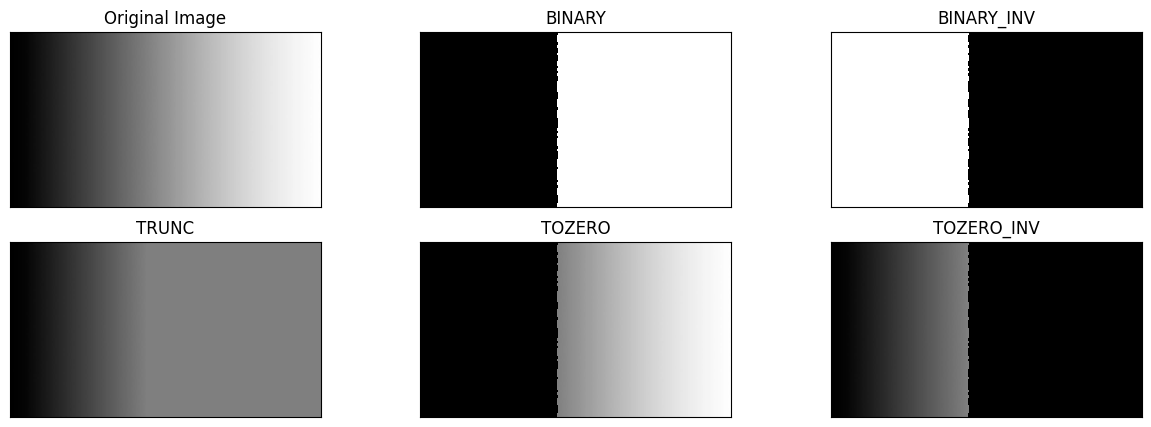

In [138]:
# Global Threshold
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
filename = ('/content/drive/MyDrive/citrapcvk/gradient.jpg')
img = cv.imread(filename)
thresh = 127 #nilai Threshold yang ditentukan
#1. thresh1 jika pixel di img>127, maka thresh1 bernilai 1(putih) selainitu bernilai 0(hitam)
ret,thresh1 = cv.threshold(img,thresh,255,cv.THRESH_BINARY)
#2. thresh2 adalah binary threshold inverse
ret,thresh2 = cv.threshold(img,thresh,255,cv.THRESH_BINARY_INV)
#3. Threshold Truncate
ret,thresh3 = cv.threshold(img,thresh,255,cv.THRESH_TRUNC)
#4. Threshold Tozero
ret,thresh4 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO)
#5. Threshold Tozero Inverse
ret,thresh5 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO_INV)
titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
plt.figure(figsize = (15,5))
for i in range(len(images)):
 plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
 plt.title(titles[i])
 plt.xticks([]),plt.yticks([])
plt.show()

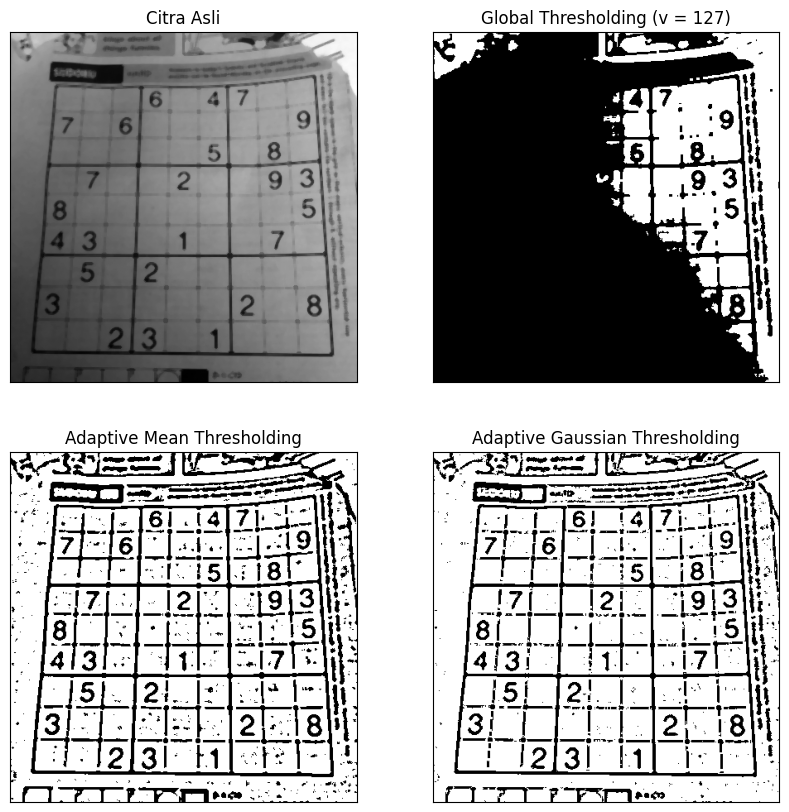

In [139]:
# Adaptive Threshold
filename = ('/content/drive/MyDrive/citrapcvk/sudoku-original.jpg')
citra = cv.medianBlur(cv.imread(filename),5)
gray = cv.cvtColor(citra, cv.COLOR_BGR2GRAY)
#gray = cv.medianBlur(gray,5)
thresh = 127
ret,th1 = cv.threshold(gray,thresh,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_MEAN_C, cv
.THRESH_BINARY,11,2)
th3 = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C
, cv.THRESH_BINARY,11,2)
titles = ['Citra Asli', 'Global Thresholding (v = 127)', 'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
citra2 = [gray, th1, th2, th3]
plt.figure(figsize = (10,10))
for i in range(len(citra2)):
 plt.subplot(2,2,i+1),plt.imshow(citra2[i],'gray')
 plt.title(titles[i])
 plt.xticks([]),plt.yticks([])
plt.show()

/tmp/ipython-input-942143996.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(2,2,1),plt.hist(blur.ravel(),256,[50,200])


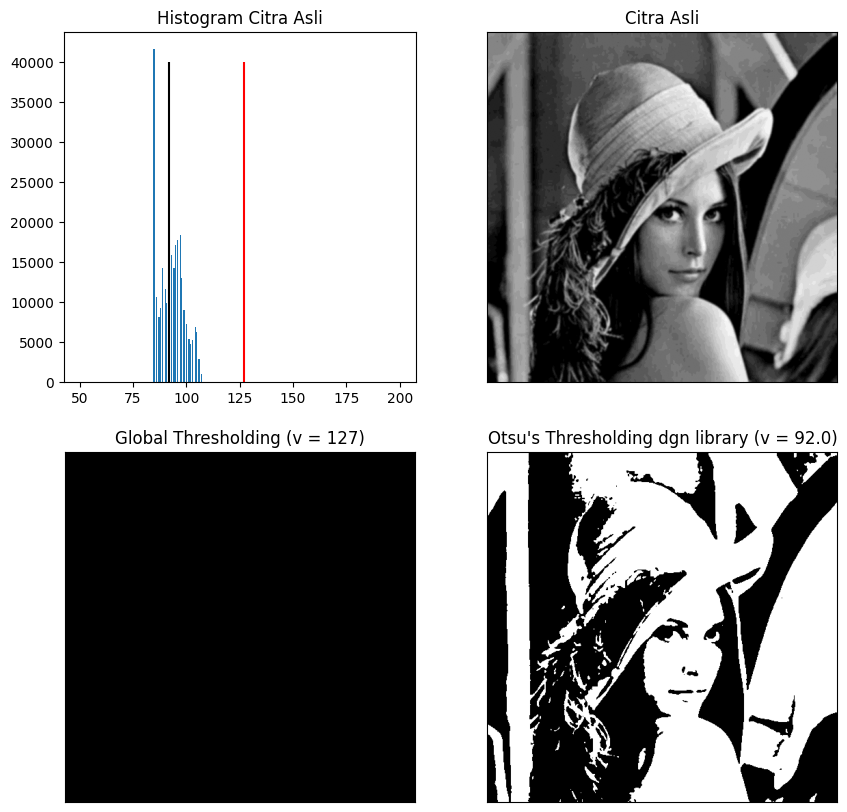

In [140]:
#  Otsu’s Threshold
# Dengan Library
filename = ('/content/drive/MyDrive/citrapcvk/lena_gs_lc2.jpg')
img = cv.imread(filename,0)
blur = cv.GaussianBlur(img,(5,5),0)
thresh = 127
ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)
ret2,th2 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
x = ("Otsu's Thresholding dgn library (v = ")+str(ret2)+")"
titles = ['Citra Asli', 'Global Thresholding (v = 127)', x]
citra3 = [blur, th1, th2]
plt.figure(figsize = (10,10))
plt.subplot(2,2,1),plt.hist(blur.ravel(),256,[50,200])
plt.vlines(ret,0,40000,colors='red') #garis vertikal merah menunjukan threshold global 127
plt.vlines(ret2,0,40000,colors='black') #garis vertikal hitam menunjukkan threshold 92 hasil otsu's
plt.title('Histogram Citra Asli')
for i in range(len(citra3)):
 plt.subplot(2,2,i+2),plt.imshow(citra3[i],'gray')
 plt.title(titles[i])
 plt.xticks([]),plt.yticks([])
plt.show()

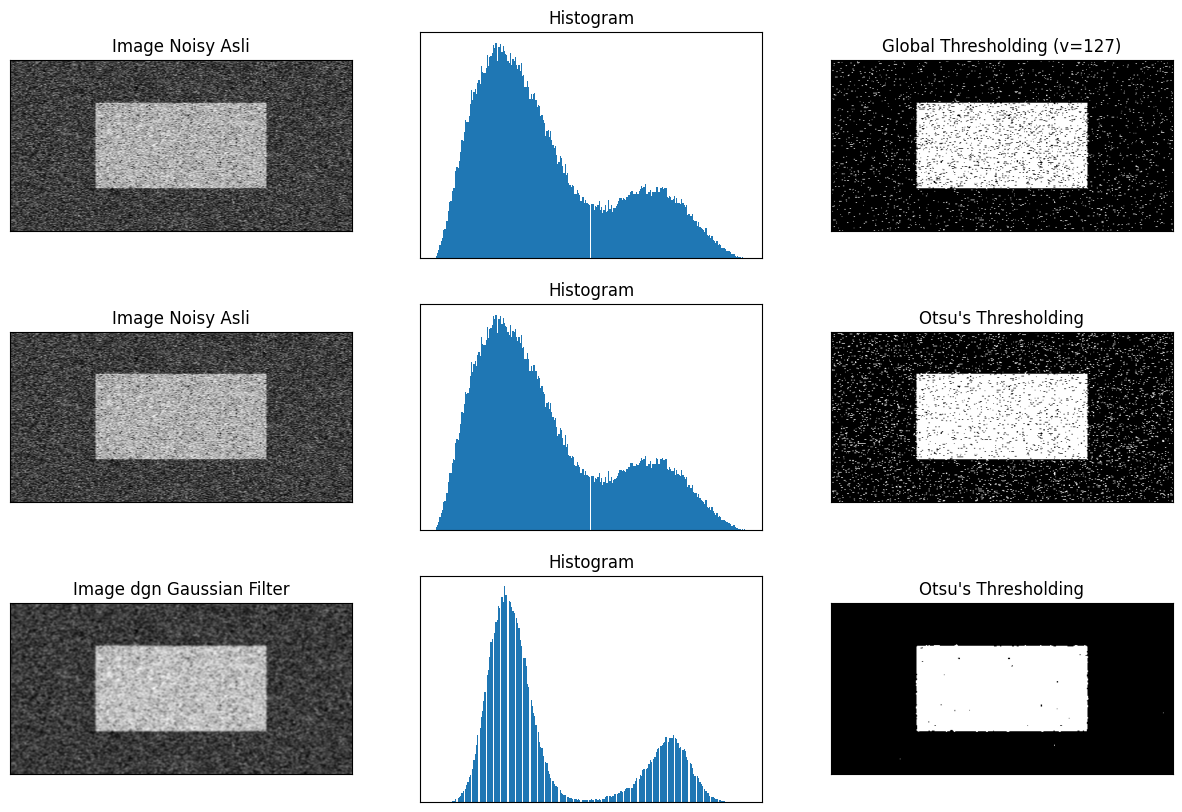

In [141]:
filename = ('/content/drive/MyDrive/citrapcvk/noisy2.png')
img = cv.imread(filename,0)
#Global Thresholding
ret1,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
# Otsu's thresholding
ret2,th2 = cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
# Otsu's thresholding setelah dilakukan Gaussian filtering
blur = cv.GaussianBlur(img,(5,5),0)
ret3,th3 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
#plotting semua image
images = [img, 0, th1,
 img, 0, th2,
 blur, 0, th3]
titles = ['Image Noisy Asli','Histogram','Global Thresholding (v=127)', 'Image Noisy Asli','Histogram',"Otsu's Thresholding", 'Image dgn Gaussian Filter','Histogram',"Otsu's Thresholding"]
plt.figure(figsize = (15,10))
for i in range(3):
 plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray')
 plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
 plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
 plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
 plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
 plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])
plt.show()

(<Axes: >, <matplotlib.image.AxesImage at 0x7dd5ee4e18e0>)

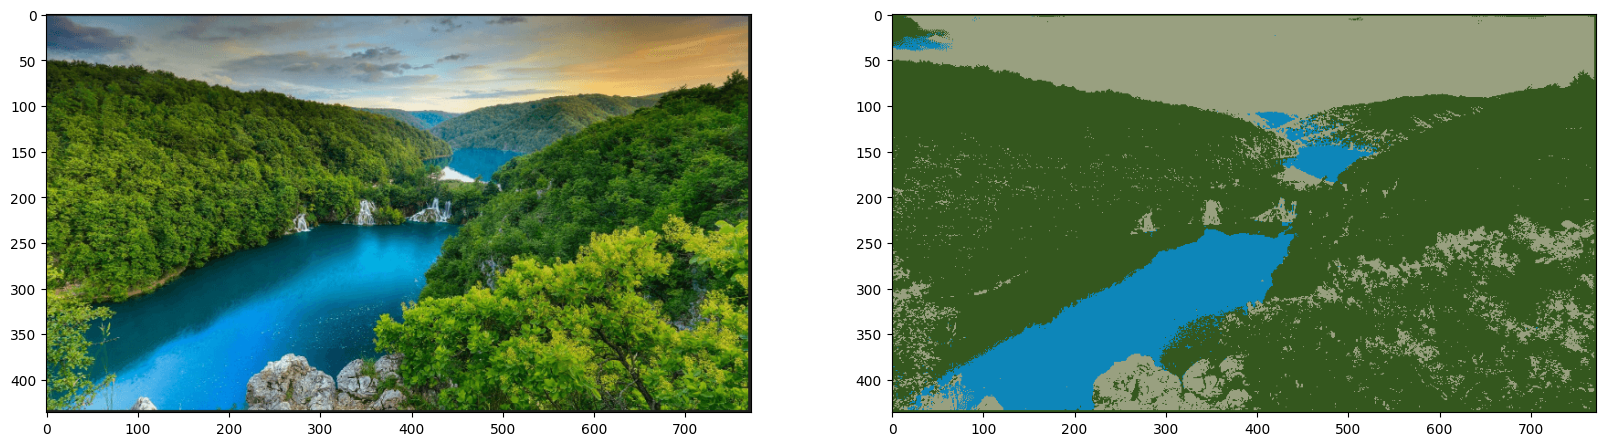

In [142]:
# Sementasi Citra menggunakan K-Means
#KMeans Image Segmentation
filename = ('/content/drive/MyDrive/citrapcvk/jungle.png')
img = cv.imread(filename)
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)
'''
kita akan menggunakan fungsi cv.kmeans() yang meminta array 2D sebagai masu
kan, sedangkan image aslinya adalah array 3D
selanjutnya kita perlu melakukan flattening array image masukan
'''
#reshape array ke bentuk 2D
pixel_values = img.reshape((-1, 3))
# convert to float
pixel_values = np.float32(pixel_values)
'''
syarat berhenti iterasi dr KMeans adalah jika centroid sudah tidak terlalu
banyak pergeseran posisi antara interasi sekarang
dengan iterasi sebelumnya (konvergen). Karena jumlah data yang besar, maka
kita akan hentikan iterasi saat jumlah iterasi = 100
atau epsilon(selisih antara posisi centroid skrg dgn posisi centroid di ite
rasi sebelumnya) < 0.2
'''
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
'''
jika diperhatikan pada image asli, terdapat 3 warna utama (hijau, biru, dan
 putih/orange). untuk percobaan ini kita akan gunakan
3 cluster untuk image ini
'''
k = 3
_, labels, (centers) = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
#konversi titik centroid kedalam integer
centers = np.uint8(centers)
#flattening label array
labels = labels.flatten()
#konversi warna pixel asli kewarna dari tiap centroidnya
segmented_image = centers[labels.flatten()]
# reshape ke bentuk image asli
segmented_image = segmented_image.reshape(img.shape)
plt.figure(figsize = (20,20))
plt.subplot(1,2,1),plt.imshow(img)
plt.subplot(1,2,2),plt.imshow(segmented_image)


(<Axes: >, <matplotlib.image.AxesImage at 0x7dd5f41afc80>)

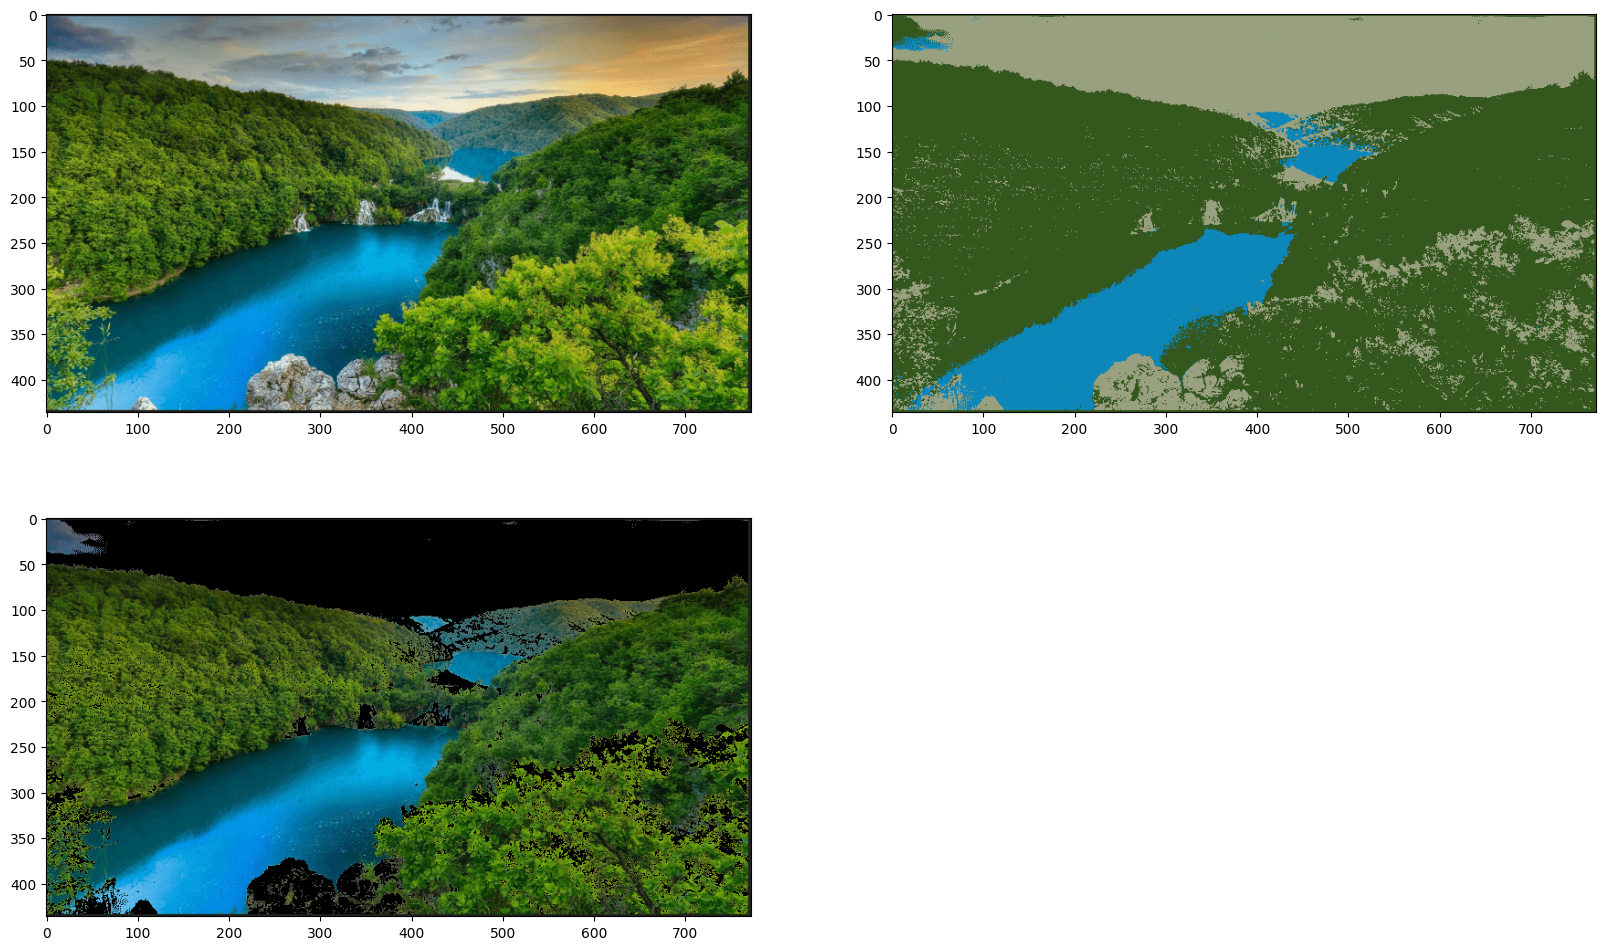

In [143]:
# Code berikut merupakan lanjutan dari code diatas yang digunakan untuk mengubah warna pada cluster tertentu.
# ubah pixel di cluster 2 menjadi hitam
masked_image = np.copy(img)
# konvert ke bentuk vektor
masked_image = masked_image.reshape((-1, 3))
# cluster yang diubah
cluster = 2
masked_image[labels == cluster] = [0, 0, 0]
# konvert ke bentuk asli
masked_image = masked_image.reshape(img.shape)
plt.figure(figsize = (20,12))
plt.subplot(2,2,1),plt.imshow(img)
plt.subplot(2,2,2),plt.imshow(segmented_image)
plt.subplot(2,2,3),plt.imshow(masked_image)

# **D. TUGAS PRAKTIKUM**

In [144]:
# Buat Global Threshold (BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV), dengan
# threshold= 170, secara manual sesuai dengan deskripsi dari grafik yang ditunjukkan di atas.

In [145]:
# ret,thresh1 = cv.threshold(img,thresh,255,cv.THRESH_BINARY)
def manual_threshold(img, thresh, max_value=255):
  """
  Melakukan threshold biner secara manual (tanpa cv.threshold).

  Parameters:
      img: numpy array (grayscale image)
      thresh: nilai ambang batas
      max_value: nilai maksimum output (default: 255)

  Returns:
      ret: nilai threshold (sama seperti input)
      thresh_img: citra hasil threshold
  """
  # Pastikan gambar dalam bentuk numpy array tipe uint8
  img = np.array(img, dtype=np.uint8)

  # Buat array kosong dengan ukuran sama
  thresh_img = np.zeros_like(img)

  # Terapkan threshold manual
  thresh_img[img > thresh] = max_value
  thresh_img[img <= thresh] = 0

  ret = thresh
  return ret, thresh_img

In [146]:
# ret,thresh2 = cv.threshold(img,thresh,255,cv.THRESH_BINARY_INV)
def manual_threshold_inv(img, thresh, max_value=255):
    """
    Melakukan threshold biner invers secara manual (tanpa cv.threshold).

    Parameters:
        img: numpy array (grayscale image)
        thresh: nilai ambang batas
        max_value: nilai maksimum output (biasanya 255)

    Returns:
        ret: nilai threshold (sama seperti input)
        thresh_img: citra hasil threshold invers
    """
    # Pastikan gambar dalam bentuk numpy array tipe uint8
    img = np.array(img, dtype=np.uint8)

    # Buat array kosong dengan ukuran sama
    thresh_img = np.zeros_like(img)

    # Terapkan threshold invers manual
    thresh_img[img > thresh] = 0
    thresh_img[img <= thresh] = max_value

    ret = thresh
    return ret, thresh_img

In [147]:
# ret,thresh3 = cv.threshold(img,thresh,255,cv.THRESH_TRUNC)
def manual_threshold_trunc(img, thresh, max_value=255):
    """
    Melakukan threshold dengan mode TRUNC secara manual (tanpa cv.threshold).

    Parameters:
        img: numpy array (grayscale image)
        thresh: nilai ambang batas
        max_value: tidak digunakan di mode TRUNC, hanya untuk konsistensi argumen

    Returns:
        ret: nilai threshold (sama seperti input)
        thresh_img: citra hasil threshold TRUNC
    """
    # Pastikan gambar numpy uint8
    img = np.array(img, dtype=np.uint8)

    # Buat salinan gambar agar tidak mengubah aslinya
    thresh_img = img.copy()

    # Terapkan threshold TRUNC manual
    thresh_img[img > thresh] = thresh  # nilai di atas ambang dipotong ke thresh

    ret = thresh
    return ret, thresh_img

In [148]:
# ret,thresh4 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO)
def manual_threshold_tozero(img, thresh, max_value=255):
    """
    Melakukan threshold dengan mode TOZERO secara manual (tanpa cv.threshold).

    Parameters:
        img: numpy array (grayscale image)
        thresh: nilai ambang batas
        max_value: tidak digunakan di mode TOZERO, hanya untuk konsistensi argumen

    Returns:
        ret: nilai threshold (sama seperti input)
        thresh_img: citra hasil threshold TOZERO
    """
    # Pastikan gambar dalam format numpy uint8
    img = np.array(img, dtype=np.uint8)

    # Buat salinan gambar untuk hasil
    thresh_img = img.copy()

    # Terapkan threshold TOZERO manual
    thresh_img[img <= thresh] = 0  # piksel di bawah atau sama ambang jadi 0

    ret = thresh
    return ret, thresh_img

In [149]:
# ret,thresh5 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO_INV)
def manual_threshold_tozero_inv(img, thresh, max_value=255):
    """
    Melakukan threshold dengan mode TOZERO_INV secara manual (tanpa cv.threshold).

    Parameters:
        img: numpy array (grayscale image)
        thresh: nilai ambang batas
        max_value: tidak digunakan di mode ini, hanya untuk konsistensi argumen

    Returns:
        ret: nilai threshold (sama seperti input)
        thresh_img: citra hasil threshold TOZERO_INV
    """
    # Pastikan gambar berupa numpy array tipe uint8
    img = np.array(img, dtype=np.uint8)

    # Buat salinan untuk hasil
    thresh_img = img.copy()

    # Terapkan threshold TOZERO_INV manual
    thresh_img[img > thresh] = 0  # piksel di atas ambang jadi 0

    ret = thresh
    return ret, thresh_img

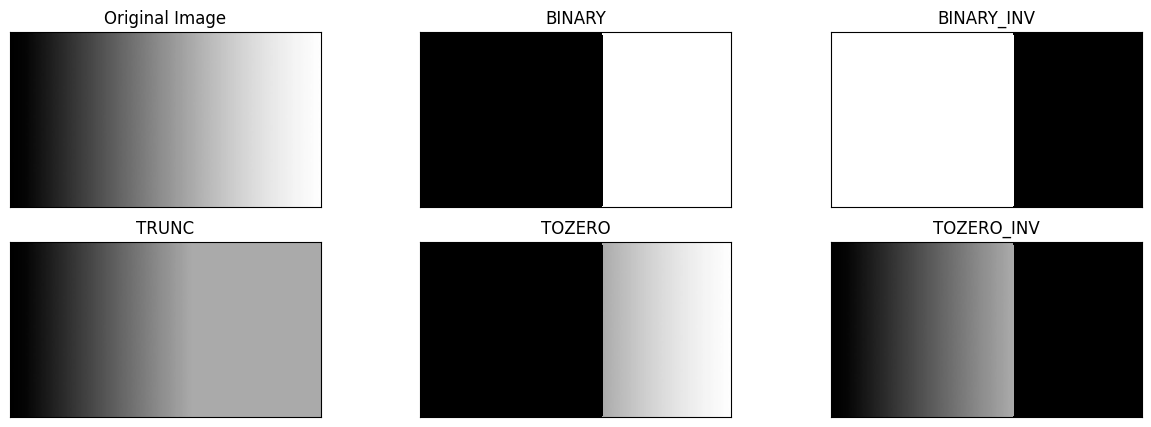

In [150]:
grad = ('/content/drive/MyDrive/citrapcvk/gradient.jpg')
img = cv.imread(grad)
thresh = 170 #nilai Threshold yang ditentukan
ret,thresh1 = manual_threshold(img,thresh,255)
ret,thresh2 = manual_threshold_inv(img,thresh,255)
ret,thresh3 = manual_threshold_trunc(img,thresh,255)
ret,thresh4 = manual_threshold_tozero(img,thresh,255)
ret,thresh5 = manual_threshold_tozero_inv(img,thresh,255)
titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
plt.figure(figsize = (15,5))
for i in range(len(images)):
 plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
 plt.title(titles[i])
 plt.xticks([]),plt.yticks([])
plt.show()

In [151]:
# Buat Otsu Thresholding tanpa menggunakan Library. Tampilkan juga nilai threshold
# saat anda gunakan Otsu’s, seperti terlihat pada gambar hasil berikut. (gunakan image
# balloon.jpg agar terlihat beda antara hasil otsu’s dengan global threshold biasa)
def manual_otsu_threshold(img, max_value=255):
    """
    Melakukan Otsu's Binarization secara manual (tanpa cv.threshold).

    Parameters:
        img: numpy array (grayscale image)
        max_value: nilai maksimum (biasanya 255)

    Returns:
        ret: nilai threshold optimal hasil perhitungan Otsu
        thresh_img: citra hasil threshold biner
    """
    # Pastikan gambar grayscale dan numpy uint8
    img = np.array(img, dtype=np.uint8)

    # Hitung histogram (256 bin, dari 0-255)
    hist, bins = np.histogram(img.ravel(), 256, [0, 256])

    # Jumlah total piksel
    total = img.size

    # Inisialisasi variabel
    current_max, threshold = 0, 0
    sum_total, sum_foreground, weight_background, weight_foreground = 0, 0, 0, 0

    # Total jumlah piksel dikalikan intensitas
    sum_total = np.dot(np.arange(256), hist)

    for t in range(256):
        weight_background += hist[t]                     # bobot background
        if weight_background == 0:
            continue
        weight_foreground = total - weight_background
        if weight_foreground == 0:
            break

        sum_foreground += t * hist[t]

        mean_back = sum_foreground / weight_background
        mean_fore = (sum_total - sum_foreground) / weight_foreground

        # Varians antar kelas
        between_var = weight_background * weight_foreground * (mean_back - mean_fore) ** 2

        # Simpan threshold dengan varians antar-kelas terbesar
        if between_var > current_max:
            current_max = between_var
            threshold = t

    # Terapkan THRESH_BINARY dengan ambang hasil Otsu
    thresh_img = np.zeros_like(img)
    thresh_img[img > threshold] = max_value
    thresh_img[img <= threshold] = 0

    ret = threshold
    return ret, thresh_img

/tmp/ipython-input-312624354.py:11: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(2,2,1),plt.hist(blur.ravel(),256,[50,200])


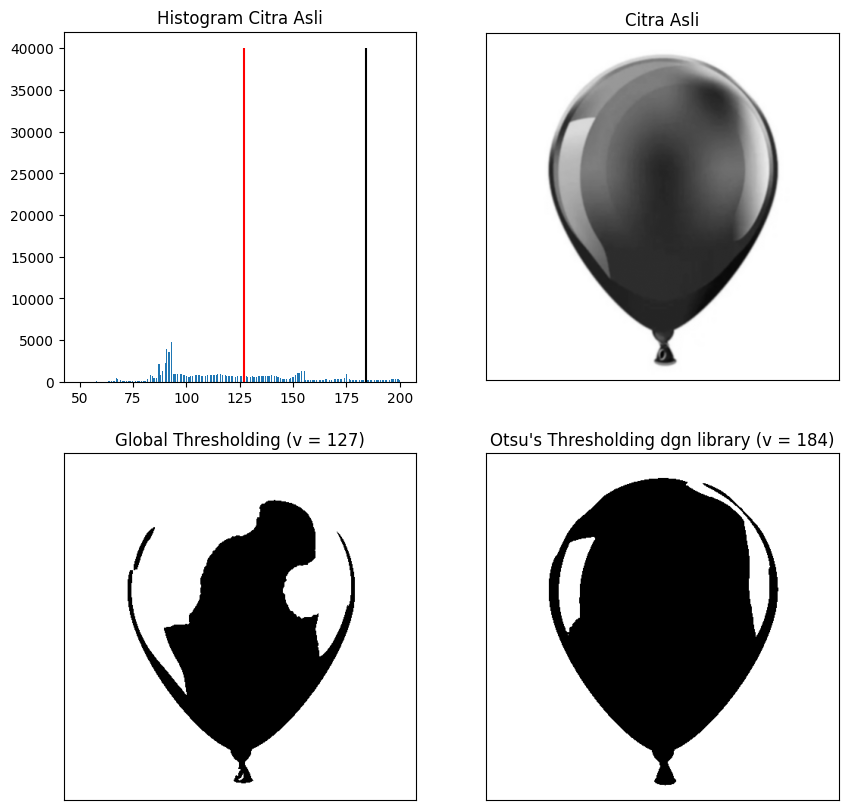

In [152]:
balon = ('/content/drive/MyDrive/citrapcvk/balon.jpg')
img = cv.imread(balon,0)
blur = cv.GaussianBlur(img,(5,5),0)
thresh = 127
ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)
ret2,th2 = manual_otsu_threshold(blur,255)
x = ("Otsu's Thresholding dgn library (v = ")+str(ret2)+")"
titles = ['Citra Asli', 'Global Thresholding (v = 127)', x]
citra3 = [blur, th1, th2]
plt.figure(figsize = (10,10))
plt.subplot(2,2,1),plt.hist(blur.ravel(),256,[50,200])
plt.vlines(ret,0,40000,colors='red') #garis vertikal merah menunjukan threshold global 127
plt.vlines(ret2,0,40000,colors='black') #garis vertikal hitam menunjukkan threshold 92 hasil otsu's
plt.title('Histogram Citra Asli')
for i in range(len(citra3)):
 plt.subplot(2,2,i+2),plt.imshow(citra3[i],'gray')
 plt.title(titles[i])
 plt.xticks([]),plt.yticks([])
plt.show()

5. Buat histogram dari citra tersegmentasi, Histogram hanya pada foreground image
saja. Gunakan image tobacco.jpg yang sudah disediakan di folder images.

Petunjuk:

a. anda dapat gunakan cv.calcHist untuk menampilkan histogram.

b. Buka link berikut https://opencvtutorial.readthedocs.io/en/latest/histogram/histogram.html

c. Dari link tersebut perhatikan bahwa cv.calcHist memiliki salah satu parameter
yaitu mask. Jika diset None, maka keseluruhan image akan dihitung
histogramnya. Jika kita tentukan mask, maka hanya bagian image yang
dimasking warna putih yang akan dihitung histogramnya (dari contoh
dibawah dinamakan dengan Citra Segment).


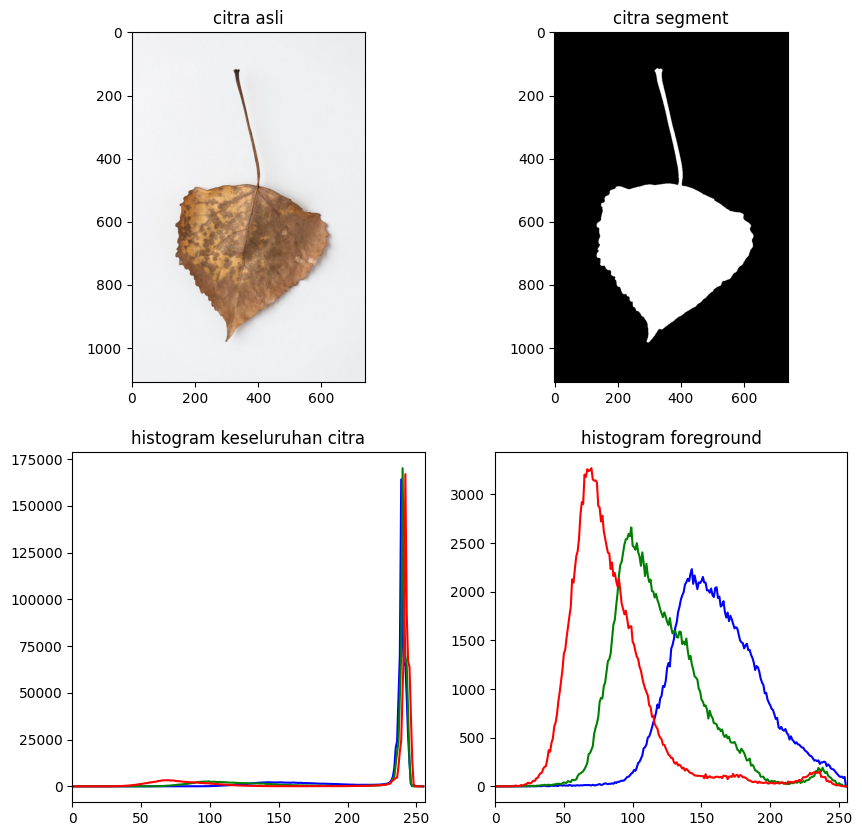

In [153]:
daun = cv.imread('/content/drive/MyDrive/citrapcvk/daun.jpg')
daun = cv.cvtColor(daun, cv.COLOR_BGR2RGB)
# plt.imshow(daun)

chans = cv.split(daun)
colors = 'b', 'g', 'r'

# Konversi ke grayscale dan blur
gray = cv.cvtColor(daun, cv.COLOR_BGR2GRAY)
blur = cv.GaussianBlur(gray, (3, 3), 0)

#  Threshold Otsu (background putih → gunakan THRESH_BINARY_INV)
_, mask = cv.threshold(blur, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)


contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
mask_final = np.zeros_like(mask)
if contours:
    c = max(contours, key=cv.contourArea)
    cv.drawContours(mask_final, [c], -1, 255, thickness=cv.FILLED)
    # sedikit dilate biar pinggiran tidak bolong
    mask_final = cv.morphologyEx(
        mask_final, cv.MORPH_DILATE,
        cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5)),
        iterations=1
    )

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(daun)
plt.title('citra asli')
# plt.xlabel('Bins')
# plt.ylabel('# of pixels')

plt.subplot(2, 2, 2)
plt.imshow(mask_final, cmap='gray')
plt.title('citra segment')

plt.subplot(2, 2, 3)
for (chan, color) in zip(chans, colors):
    hist = cv.calcHist([chan], [0], None, [256], [0, 255])
    plt.plot(hist, color=color)
    plt.title('histogram keseluruhan citra')
    plt.xlim([0, 256])
    plt.ylim()

plt.subplot(2, 2, 4)
for (chan, color) in zip(chans, colors):
    hist = cv.calcHist([chan], [0], mask_final, [256], [0, 255])
    plt.plot(hist, color=color)
    plt.title('histogram foreground')
    plt.xlim([0, 256])
    plt.ylim()

plt.show()

6. Lakukan segmentasi warna pada image "peppers.jpg", munculkan hanya warna yang
kuning saja. (Petunjuk: anda dapat gunakan K-Means untuk menampilkan hanya
warna tertentu saja)

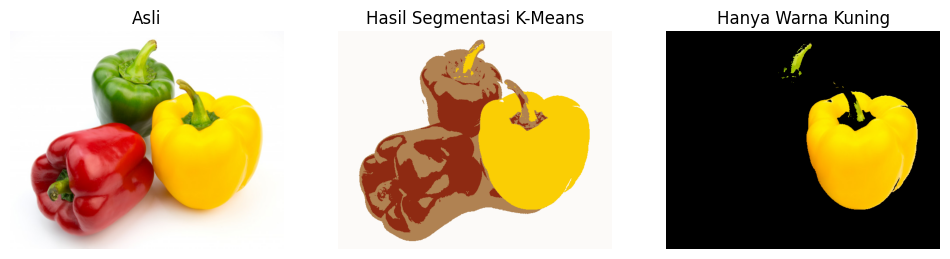

In [154]:
pep = cv.imread('/content/drive/MyDrive/citrapcvk/peppers.jpg')
pep = cv.cvtColor(pep, cv.COLOR_BGR2RGB)

# Ubah menjadi array 2D
Z = pep.reshape((-1, 3))
Z = np.float32(Z)

# Tentukan k (jumlah cluster)
K = 4
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
_, labels, centers = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# Konversi ke uint8
centers = np.uint8(centers)
segmented_pep = centers[labels.flatten()]
segmented_pep = segmented_pep.reshape((pep.shape))

# Cari cluster warna kuning
mask_yellow = cv.inRange(segmented_pep, (200, 200, 0), (255, 255, 100))

# Gunakan mask untuk menampilkan hanya area kuning
result = cv.bitwise_and(pep, pep, mask=mask_yellow)

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.title('Asli')
plt.imshow(pep)
plt.axis('off')

plt.subplot(1,3,2)
plt.title('Hasil Segmentasi K-Means')
plt.imshow(segmented_pep)
plt.axis('off')

plt.subplot(1,3,3)
plt.title('Hanya Warna Kuning')
plt.imshow(result)
plt.axis('off')

plt.show()

Saat anda menampilkan warna tertentu, jelaskan kendala yang di hadapi dan mengapa
hal itu terjadi.


warna kuning tidakk selalu memiliki nilai rgb yang sama, tergantung pada pencahayaan. pada kuning yang ada pada gambar bisa menggunakan range rgb (200-255, 200-255, 0-100) untuk mendapatkan hasil yang maksimal.

kesulitan menentukan jumlah K yang tepat pada kmeans. jika nilai k terlalu kecil, warna tidak akan terlalu beragaam, jika k terlalu besar warna kuning bisa terpecah terlalu banyak. sehingga k yang tepat adalah 4

7. Buka File crossword.jpg. Dengan pengetahuan tentang thresholding yang sudah anda
pelajari. Lakukan thresholding biner dengan hasil terbaik menurut anda. Copas code
dan hasil image di modul ini.



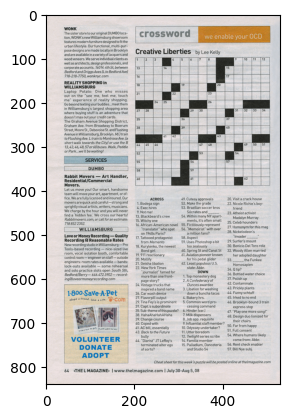

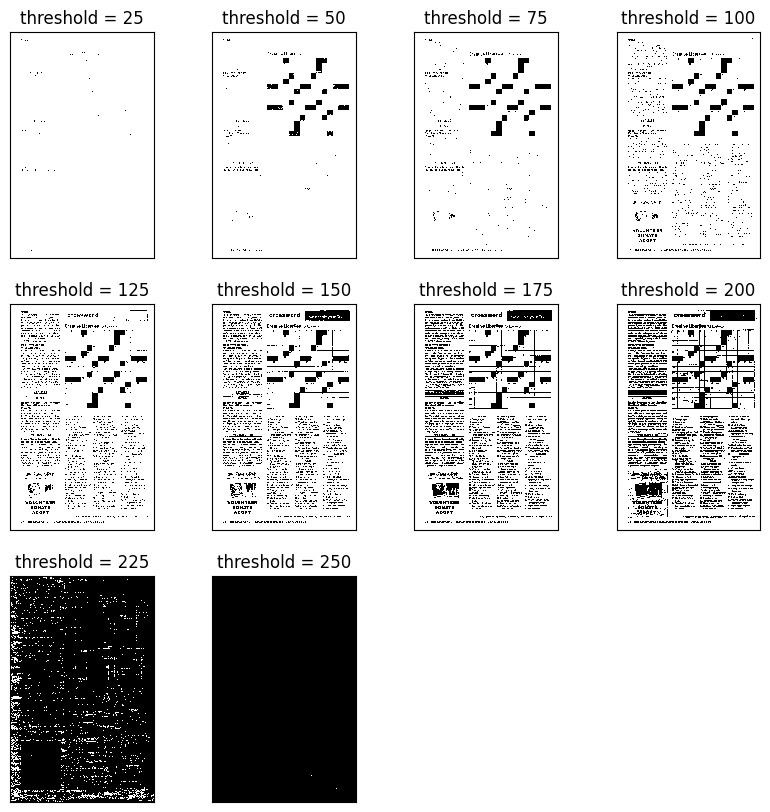

In [155]:
crossword = cv.imread('/content/drive/MyDrive/citrapcvk/crossword.jpg')
crossword = cv.cvtColor(crossword, cv.COLOR_BGR2RGB)
crossword_gray = cv.cvtColor(crossword, cv.COLOR_RGB2GRAY)
plt.imshow(crossword)
thresh = [25,50,75,100,125,150,175,200,225,250]
plt.figure(figsize=(10,10))
for i in range(len(thresh)):
  ret, th = cv.threshold(crossword_gray, thresh[i], 255, cv.THRESH_BINARY)
  plt.subplot(3,4,i+1), plt.imshow(th, cmap='gray', interpolation='nearest')
  plt.title('threshold = '+str(thresh[i]))
  plt.xticks([]),plt.yticks([])
plt.show()

threshold terbaik adalah antara 175 hingga 200 karena memberikan kontras terbaik antara elemen gambar yang relevan dan latar belakang.